<a href="https://colab.research.google.com/github/kaii0802/CS-5530---Kai-Son/blob/main/Assignments/Assignment%201/q2_student_performance/src/q2_student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2 - Students Performance

Three-stage workflow: **ingest -> process -> analyze** (5 required figures, 800x600 px @ 300 DPI).

## Stage 1 - Ingest

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from PIL import Image
from matplotlib.patches import Patch


# The notebook lives in <question>/src/, so the question folder is its parent.
ROOT = Path("/content/CS-5530---Kai-Son/Assignments/Assignment 1/q2_student_performance")
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
(ROOT / "data" / "raw").mkdir(parents=True, exist_ok=True)
(ROOT / "figures").mkdir(parents=True, exist_ok=True)
(ROOT / "reports").mkdir(parents=True, exist_ok=True)

# Every figure must be 800x600 px at 300 DPI -> a small canvas, so fonts are set small on purpose.
DPI = 300
FIGSIZE = (800 / DPI, 600 / DPI)
plt.rcParams.update({
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6, "legend.title_fontsize": 6,
})

In [42]:
df = pd.read_csv(ROOT / "data" / "raw" / "StudentsPerformance.csv")

print("--- Stage 1: Ingest complete ---")
print(f"Shape: {df.shape}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")
df.head()

--- Stage 1: Ingest complete ---
Shape: (1000, 8)
Missing values: 0
Duplicate rows: 0


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Stage 2 - Process


In [43]:
# Clean column names -> short snake_case names (easier to code with)
df.columns = [c.strip().lower().replace(" ", "_").replace("/", "_") for c in df.columns]
df = df.rename(columns={
    "parental_level_of_education": "parent_edu",
    "test_preparation_course": "test_prep",
    "math_score": "math",
    "reading_score": "reading",
    "writing_score": "writing",
})

# Missing values / duplicates / out-of-range scores (none expected in this file, but check anyway)
scores = ["math", "reading", "writing"]
rows_before = len(df)
df = df.dropna(subset=scores).drop_duplicates()
df = df[df[scores].apply(lambda s: s.between(0, 100)).all(axis=1)]
print(f"Rows dropped (missing / duplicate / out-of-range): {rows_before - len(df)}")

# Derived column used by V3
df["overall_avg"] = df[scores].mean(axis=1).round(2)

df.to_csv(ROOT / "data" / "processed" / "students_clean.csv", index=False)
print("--- Stage 2: Process complete, clean data saved ---")
print(f"Saved to: {(ROOT / 'data' / 'processed' / 'students_clean.csv').relative_to(ROOT)}")
df.head()

Rows dropped (missing / duplicate / out-of-range): 0
--- Stage 2: Process complete, clean data saved ---
Saved to: data/processed/students_clean.csv


,gender,race_ethnicity,parent_edu,lunch,test_prep,math,reading,writing,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


## Stage 3 - Analyze

### V1 - Gender boxplots (math vs reading)

*Question: are there gender differences in math vs reading?*

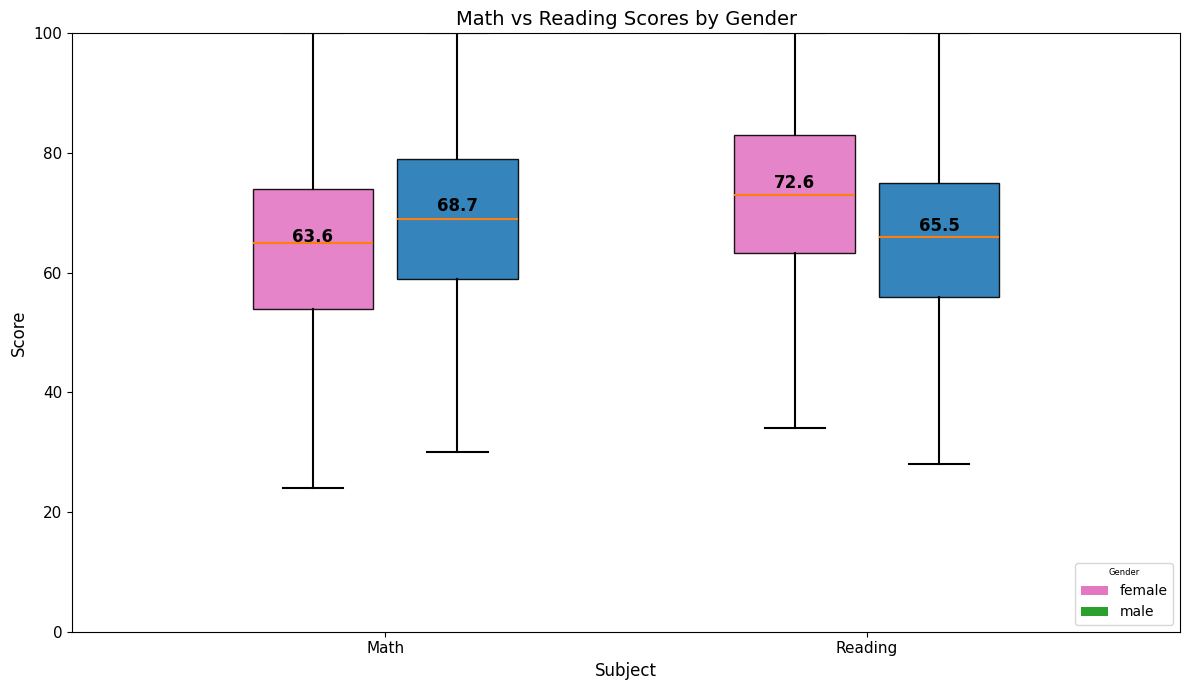

Saved: figures/v1_gender_boxplots.png (800x600 px, 300 DPI)
        math  reading
gender               
female  63.6     72.6
male    68.7     65.5


In [44]:
# --- Split data by gender ---
f_math = df.loc[df["gender"] == "female", "math"]
m_math = df.loc[df["gender"] == "male", "math"]
f_read = df.loc[df["gender"] == "female", "reading"]
m_read = df.loc[df["gender"] == "male", "reading"]

# --- Build side-by-side boxplots for each subject ---
data = [f_math, m_math, f_read, m_read]
positions = [0.85, 1.15, 1.85, 2.15]
width = 0.25


with plt.rc_context({"font.size": 10, "axes.titlesize": 14, "axes.labelsize": 12,
                      "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10}):
    plt.figure(figsize=(12, 7))
    bp = plt.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        showfliers=False
    )

    # Colors
    colors = ["tab:pink", "tab:blue", "tab:pink", "tab:blue"]
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.9)

    # Style lines
    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set_linewidth(1.5)

    # ---------- ADD MEAN NUMBERS ----------
    means = [d.mean() for d in data]
    for pos, mean in zip(positions, means):
        plt.text(
            pos,
            mean + 1.5,             # small offset above box
            f"{mean:.1f}",
            ha="center",
            fontsize=12,
            fontweight="bold"
        )

    # X axis labels
    plt.xticks([1, 2], ["Math", "Reading"])
    plt.xlabel("Subject")
    plt.ylabel("Score")
    plt.title("Math vs Reading Scores by Gender")

    # Legend
    legend_handles = [
        Patch(facecolor="tab:pink", label="female"),
        Patch(facecolor="tab:green", label="male"),
    ]
    plt.legend(handles=legend_handles, title="Gender", loc="lower right")

    plt.ylim(0, 100)
    plt.tight_layout()

    tmp_path = ROOT / "figures" / "_tmp_v1.png"
    plt.savefig(tmp_path, dpi=150)
    plt.show()

# Shrink the saved copy down to exactly 800x600 px at 300 DPI
img = Image.open(tmp_path).resize((800, 600))
img.save(ROOT / "figures" / "v1_gender_boxplots.png", dpi=(300, 300))
tmp_path.unlink()

print("Saved: figures/v1_gender_boxplots.png (800x600 px, 300 DPI)")
print(df.groupby("gender")[["math", "reading"]].mean().round(1))

### V2 - Test prep impact on math

*Question: do students who completed test prep score higher in math?*

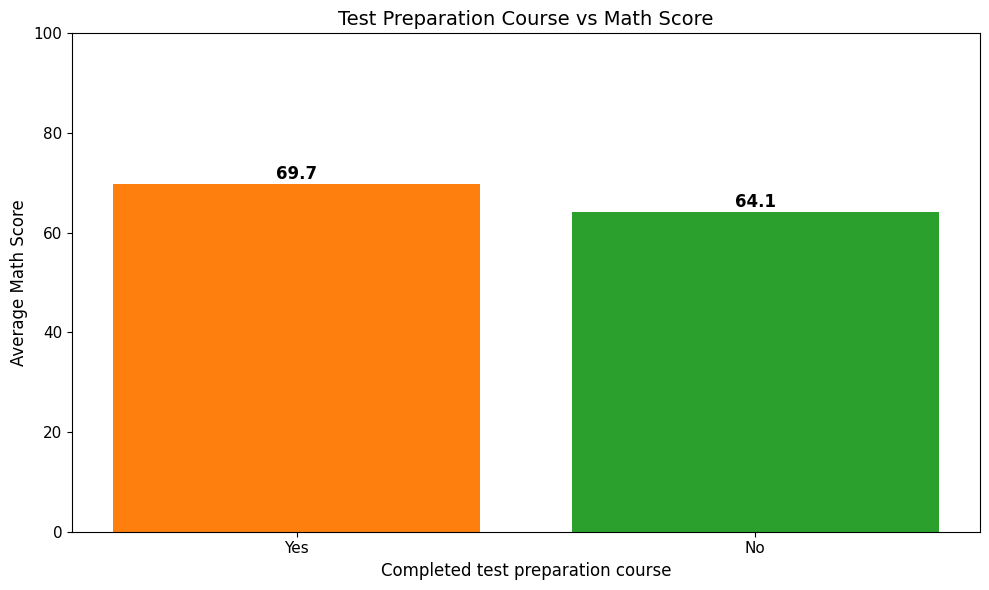

Saved: figures/v2_test_prep_math.png (800x600 px, 300 DPI)
test_prep
completed    69.695531
none         64.077882
Name: math, dtype: float64


In [45]:
# --- Compute averages ---
avg_scores = df.groupby("test_prep")["math"].mean().sort_index()

# Display as No/Yes (only changes the labels, not the data)
label_map = {"none": "No", "completed": "Yes"}
labels = [label_map.get(str(x), str(x)) for x in avg_scores.index]
values = avg_scores.values

# 800x600 px / 300 DPI the assignment asks for.
with plt.rc_context({"font.size": 10, "axes.titlesize": 14, "axes.labelsize": 12,
                      "xtick.labelsize": 11, "ytick.labelsize": 11}):
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, values, color=["tab:orange", "tab:green"])

    # --- Add numbers on bars ---
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + 1,
            f"{h:.1f}",
            ha="center",
            fontsize=12,
            fontweight="bold"
        )

    plt.title("Test Preparation Course vs Math Score")
    plt.xlabel("Completed test preparation course")
    plt.ylabel("Average Math Score")
    plt.ylim(0, 100)
    plt.tight_layout()

    tmp_path = ROOT / "figures" / "_tmp_v2.png"
    plt.savefig(tmp_path, dpi=150)
    plt.show()

# Shrink the saved copy down to exactly 800x600 px at 300 DPI
img = Image.open(tmp_path).resize((800, 600))
img.save(ROOT / "figures" / "v2_test_prep_math.png", dpi=(300, 300))
tmp_path.unlink()

print("Saved: figures/v2_test_prep_math.png (800x600 px, 300 DPI)")
print(avg_scores)

### V3 - Lunch type and average performance

*Question: does lunch type relate to outcomes?*

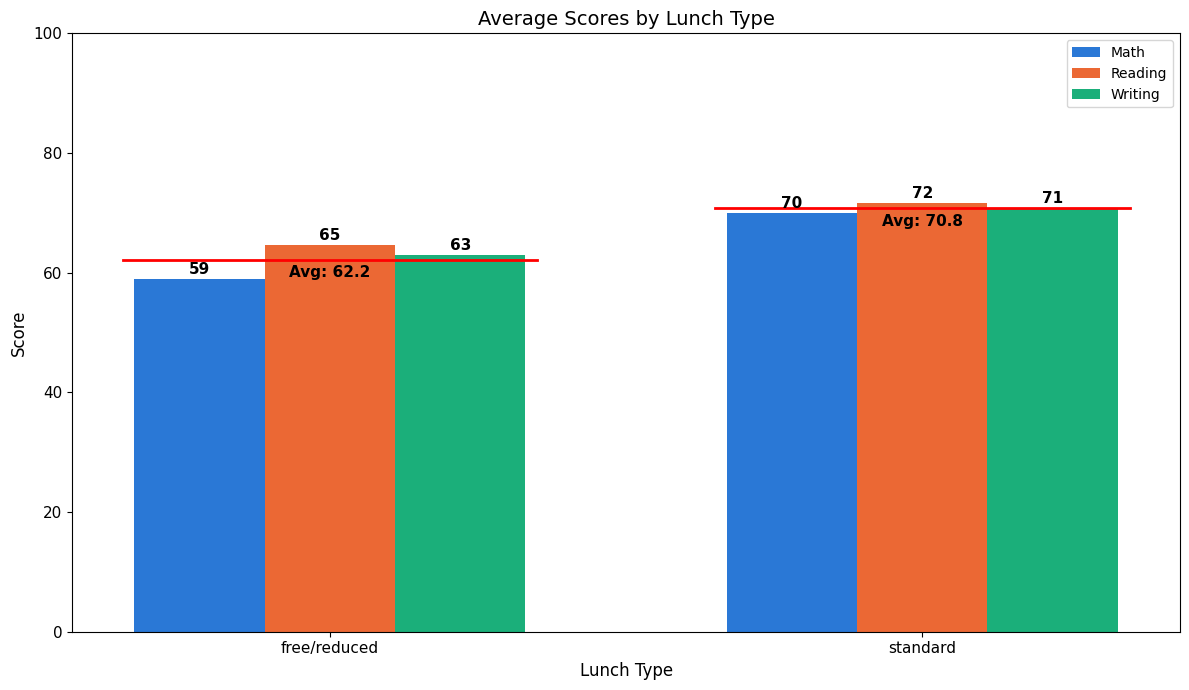

Saved: figures/v3_lunch_average.png (800x600 px, 300 DPI)


,math,reading,writing
lunch,,,
free/reduced,58.9,64.7,63.0
standard,70.0,71.7,70.8


In [46]:
# --- Compute averages ---
grouped = df.groupby("lunch")[["math", "reading", "writing"]].mean().round(1)
labels = grouped.index.tolist()
math_vals = grouped["math"].values
read_vals = grouped["reading"].values
write_vals = grouped["writing"].values

x = np.arange(len(labels))
width = 0.22

# Draw it big and readable first, then shrink the SAVED file down to the exact
# 800x600 px / 300 DPI the assignment asks for.
with plt.rc_context({"font.size": 10, "axes.titlesize": 14, "axes.labelsize": 12,
                      "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10}):
    plt.figure(figsize=(12, 7))

    colors = ["#2a78d6", "#eb6834", "#1baf7a"]   # blue, orange, aqua
    bars1 = plt.bar(x - width, math_vals, width, label="Math", color=colors[0])
    bars2 = plt.bar(x, read_vals, width, label="Reading", color=colors[1])
    bars3 = plt.bar(x + width, write_vals, width, label="Writing", color=colors[2])

    # --- Add numbers on bars ---
    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8,
                f"{h:.0f}",
                ha="center",
                fontsize=11,
                fontweight="bold"
            )

    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)

    # --- Average line per group ---
    for i in range(len(labels)):
        avg_val = np.mean([math_vals[i], read_vals[i], write_vals[i]])
        plt.plot([i - 0.35, i + 0.35], [avg_val, avg_val], color="red", linewidth=2)
        plt.text(i, avg_val - 3, f"Avg: {avg_val:.1f}", ha="center", fontsize=11, fontweight="bold")

    plt.xticks(x, labels)
    plt.ylabel("Score")
    plt.xlabel("Lunch Type")
    plt.title("Average Scores by Lunch Type")
    plt.legend()
    plt.ylim(0, 100)
    plt.tight_layout()

    tmp_path = ROOT / "figures" / "_tmp_v3.png"
    plt.savefig(tmp_path, dpi=150)
    plt.show()

# Shrink the saved copy down to exactly 800x600 px at 300 DPI
img = Image.open(tmp_path).resize((800, 600))
img.save(ROOT / "figures" / "v3_lunch_average.png", dpi=(300, 300))
tmp_path.unlink()

print("Saved: figures/v3_lunch_average.png (800x600 px, 300 DPI)")
grouped

### V4 - Subject correlations

*Question: how strongly do the three subjects move together?*

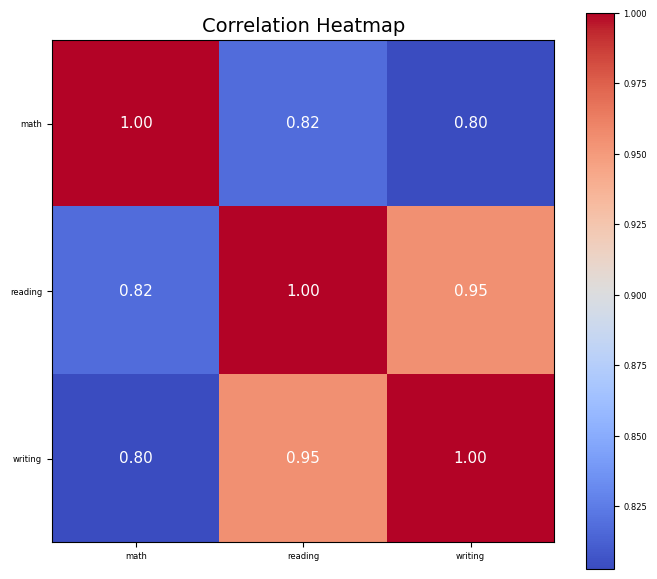

Saved: figures/v4_subject_correlations.png (800x600 px, 300 DPI)


,math,reading,writing
math,1.00,0.82,0.80
reading,0.82,1.00,0.95
writing,0.80,0.95,1.00


In [47]:
corr = df[["math", "reading", "writing"]].corr()

with plt.rc_context({"font.size": 10, "axes.titlesize": 14}):
    plt.figure(figsize=(7, 6))

    plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()

    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.index)), corr.index)

    for i in range(len(corr)):
        for j in range(len(corr)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="white", fontsize=11)

    plt.title("Correlation Heatmap")
    plt.tight_layout()

    tmp_path = ROOT / "figures" / "_tmp_v4.png"
    plt.savefig(tmp_path, dpi=150)
    plt.show()

# Shrink the saved copy down to exactly 800x600 px at 300 DPI
img = Image.open(tmp_path).resize((800, 600))
img.save(ROOT / "figures" / "v4_subject_correlations.png", dpi=(300, 300))
tmp_path.unlink()

print("Saved: figures/v4_subject_correlations.png (800x600 px, 300 DPI)")
corr.round(2)

### V5 - Math vs reading with trend lines by test prep

*Question: how strongly are math and reading associated, and does the pattern differ by test prep?*

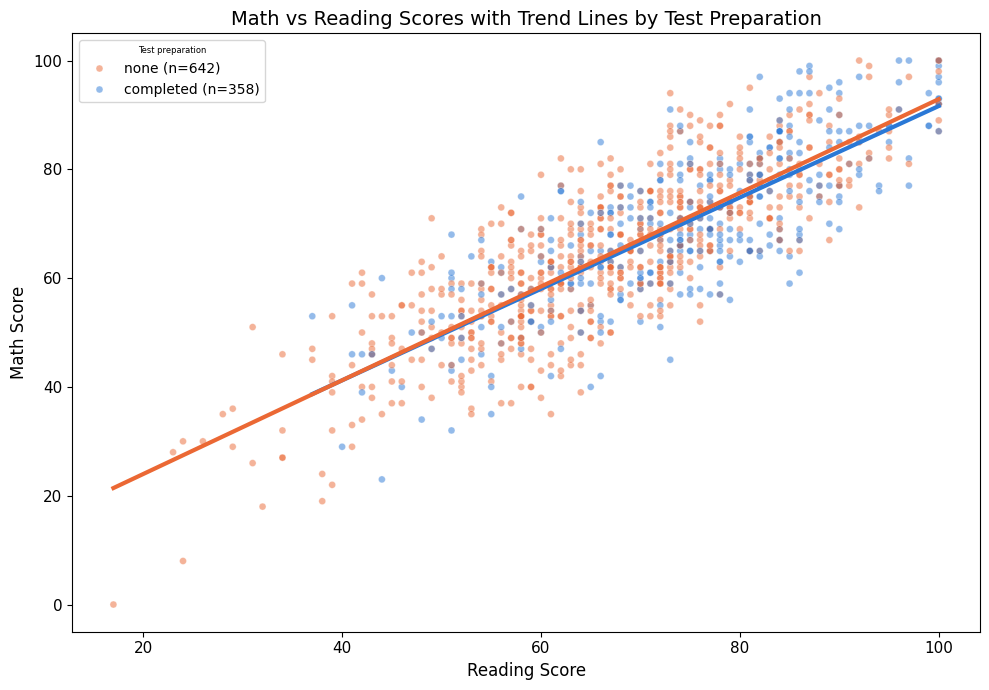

Saved: figures/v5_math_vs_reading_by_prep.png (800x600 px, 300 DPI)
test_prep
none         642
completed    358
Name: count, dtype: int64


In [48]:
palette = {
    "completed": "#2a78d6",
    "none": "#eb6834",
}

# Draw it big and readable first, then shrink the SAVED file down to the exact
# 800x600 px / 300 DPI the assignment asks for.
with plt.rc_context({"font.size": 10, "axes.titlesize": 14, "axes.labelsize": 12,
                      "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10}):
    plt.figure(figsize=(10, 7))

    # Scatter, colored by test prep, with the group size (n) in the legend label
    counts = df["test_prep"].value_counts()
    hue_labels = {g: f"{g} (n={counts[g]})" for g in palette}
    sns.scatterplot(
        data=df.assign(test_prep_label=df["test_prep"].map(hue_labels)),
        x="reading", y="math", hue="test_prep_label",
        palette={hue_labels[g]: c for g, c in palette.items()},
        alpha=0.5, s=25
    )

    # Trend lines (one per group)
    for group, color in palette.items():
        sub = df[df["test_prep"] == group]
        sns.regplot(data=sub, x="reading", y="math", scatter=False, color=color,
                    line_kws={"linewidth": 3}, ci=None)

    plt.title("Math vs Reading Scores with Trend Lines by Test Preparation")
    plt.xlabel("Reading Score")
    plt.ylabel("Math Score")
    plt.legend(title="Test preparation")
    plt.tight_layout()

    tmp_path = ROOT / "figures" / "_tmp_v5.png"
    plt.savefig(tmp_path, dpi=150)
    plt.show()

# Shrink the saved copy down to exactly 800x600 px at 300 DPI
img = Image.open(tmp_path).resize((800, 600))
img.save(ROOT / "figures" / "v5_math_vs_reading_by_prep.png", dpi=(300, 300))
tmp_path.unlink()

print("Saved: figures/v5_math_vs_reading_by_prep.png (800x600 px, 300 DPI)")
print(counts)

### Check figure specs (800x600 px, 300 DPI)


In [49]:
for path in sorted((ROOT / "figures").glob("*.png")):
    with Image.open(path) as im:
        print(f"{path.name}: {im.size[0]}x{im.size[1]} px, {round(im.info['dpi'][0])} DPI")

v1_gender_boxplots.png: 800x600 px, 300 DPI
v2_test_prep_math.png: 800x600 px, 300 DPI
v3_lunch_average.png: 800x600 px, 300 DPI
v4_subject_correlations.png: 800x600 px, 300 DPI
v5_math_vs_reading_by_prep.png: 800x600 px, 300 DPI


### Write `reports/findings.md`


In [50]:
gap_prep = df.loc[df.test_prep == "completed", "math"].mean() - df.loc[df.test_prep == "none", "math"].mean()
lunch_overall = grouped.mean(axis=1)  # simple average of math/reading/writing per lunch group
gap_lunch = lunch_overall["standard"] - lunch_overall["free/reduced"]

with open(ROOT / "reports" / "findings.md", "w", encoding="utf-8") as f:
    f.write("# Q2 - Students Performance: Findings\n\n")
    f.write(f"Rows analyzed: {len(df)} (out of {rows_before} raw rows). "
            f"{rows_before - len(df)} rows were dropped for missing values, duplicates, or "
            "out-of-range scores; this dataset happened to have none of those problems.\n\n")

    f.write("## V1 - Gender boxplots (math vs reading)\n\n")
    f.write("![V1](../figures/v1_gender_boxplots.png)\n\n")
    f.write("Males score a little higher in math on average and females score a little higher in "
            "reading. Neither gender leads in both subjects, so this looks like a trade-off rather "
            "than one group doing better overall. The boxes also show a wide spread of scores inside "
            "each gender, which is bigger than the gap between the two gender averages.\n\n")

    f.write("## V2 - Test prep impact on math\n\n")
    f.write("![V2](../figures/v2_test_prep_math.png)\n\n")
    f.write(f"Students who completed the test preparation course score about {gap_prep:.1f} points "
            "higher in math on average than students who did not. This suggests the course is "
            "associated with better math performance, although students who choose to prepare may "
            "also differ from other students in other ways.\n\n")

    f.write("## V3 - Lunch type and average performance\n\n")
    f.write("![V3](../figures/v3_lunch_average.png)\n\n")
    f.write(f"Students with standard lunch score about {gap_lunch:.1f} points higher overall than "
            "students with free/reduced lunch, and this holds in all three subjects, not just one. "
            "Lunch type is often used as a rough stand-in for family income, so this gap may reflect "
            "wider differences in resources rather than lunch itself.\n\n")

    f.write("## V4 - Subject correlations\n\n")
    f.write("![V4](../figures/v4_subject_correlations.png)\n\n")
    f.write(f"All three subjects move together: the correlation numbers range from "
            f"{corr.where(corr < 1).min().min():.2f} to {corr.where(corr < 1).max().max():.2f}, all "
            "positive, meaning a student who scores high in one subject tends to score high in the "
            "others too. Reading and writing are the most closely linked pair.\n\n")

    f.write("## V5 - Math vs reading with trend lines by test prep\n\n")
    f.write("![V5](../figures/v5_math_vs_reading_by_prep.png)\n\n")
    f.write("Math and reading scores rise together for both groups, and the two trend lines follow a "
            "very similar path across the reading range. The completed-prep line sits a bit above the "
            "other one, so test-prep students tend to score higher in math at a given reading level, "
            "not just because they read better.\n\n")

    f.write("## Conclusion\n\n")
    f.write("Test preparation and lunch type (a rough proxy for family income) are both associated "
            "with higher scores, with the lunch gap being the larger of the two. The three subjects "
            "rise and fall together, especially reading and writing. These are patterns in "
            "observational data, not proof that any one factor causes another.\n")

print("--- findings.md saved ---")
print(open(ROOT / "reports" / "findings.md", encoding="utf-8").read())

--- findings.md saved ---
# Q2 - Students Performance: Findings

Rows analyzed: 1000 (out of 1000 raw rows). 0 rows were dropped for missing values, duplicates, or out-of-range scores; this dataset happened to have none of those problems.

## V1 - Gender boxplots (math vs reading)

![V1](../figures/v1_gender_boxplots.png)

Males score a little higher in math on average and females score a little higher in reading. Neither gender leads in both subjects, so this looks like a trade-off rather than one group doing better overall. The boxes also show a wide spread of scores inside each gender, which is bigger than the gap between the two gender averages.

## V2 - Test prep impact on math

![V2](../figures/v2_test_prep_math.png)

Students who completed the test preparation course score about 5.6 points higher in math on average than students who did not. This suggests the course is associated with better math performance, although students who choose to prepare may also differ from other stu